# Notebook 3 — Segmentation Model Training (Improved U-Net + HSA)

**Paper:** *A Comprehensive Deep-Learning Framework Integrating Lesion Segmentation and Stage Classification for Enhanced Diabetic Retinopathy Diagnosis* — Incir & Bozkurt, 2026

## What this notebook does

1. Loads preprocessed `.npz` patch files from Notebook 1
2. Defines the **Improved U-Net** with residual blocks + multi-scale fusion
3. Runs **Harmony Search Algorithm (HSA)** to find optimal LR and dropout
4. Trains the U-Net for the selected lesion with best hyperparameters
5. Evaluates on the test set and plots training curves

## How to use — one lesion per Colab session

Run this notebook four times, changing `CURRENT_LESION` in Cell 2:

```
Run 1: CURRENT_LESION = 'EX'   # Hard exudates
Run 2: CURRENT_LESION = 'HE'   # Haemorrhages
Run 3: CURRENT_LESION = 'MA'   # Microaneurysms
Run 4: CURRENT_LESION = 'SE'   # Soft exudates
```

The best checkpoint is saved to Drive after every validation Dice improvement, so training
can resume if the session disconnects.

**Prerequisites:** Runtime type must be **GPU (T4)** — Runtime > Change runtime type > T4 GPU

## Cell 1 — Mount Drive & Imports

In [1]:

import os, gc, json, time, random
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers
import tensorflow.keras.backend as K



2026-06-21 06:20:13.618277: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782022813.800763      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782022813.857772      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782022814.296433      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782022814.296476      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782022814.296478      23 computation_placer.cc:177] computation placer alr

## Cell 2 — Configuration

> **Change `CURRENT_LESION` before each run:** `'EX'` -> `'HE'` -> `'MA'` -> `'SE'`

In [2]:
# ================================================================
#  CHANGE THIS between runs: 'EX', 'HE', 'MA', or 'SE'
# ================================================================
CURRENT_LESION = 'EX'

# ---- Paths ----
DATA_BASE = '/kaggle/input/datasets/joyowusuansah/dr-segmentation-patches'
MODEL_DIR = '/kaggle/working/models/segmentation'
os.makedirs(MODEL_DIR, exist_ok=True)

# ---- Training ----
INPUT_SHAPE  = (224, 224, 3)
BATCH_SIZE   = 8        # 8 is safer on free Colab T4; use 16 on Pro/A100
MAX_EPOCHS   = 500
ES_PATIENCE  = 50       # EarlyStopping patience
RLROP_WAIT   = 20       # ReduceLROnPlateau patience

# ---- LR sweep (replaces full HSA — see Cell 6 for explanation) ----
LR_CANDIDATES = [1e-6, 1e-5, 5e-5, 1e-4, 3e-4]  # 5 candidates
SWEEP_EPOCHS  = 15      # epochs per candidate (enough for clear signal)
SWEEP_SUBSET  = 500     # training patches used per candidate
SWEEP_DROPOUT = 0.3     # fixed mid-range dropout (paper range: 0.2–0.45)

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print(f'Lesion       : {CURRENT_LESION}')
print(f'Input        : {INPUT_SHAPE}  Batch: {BATCH_SIZE}')
print(f'Training     : max {MAX_EPOCHS} epochs  ES patience={ES_PATIENCE}')
print(f'LR candidates: {LR_CANDIDATES}')
print(f'Sweep        : {SWEEP_EPOCHS} epochs x {SWEEP_SUBSET} patches  dropout={SWEEP_DROPOUT}')
print(f'Model dir    : {MODEL_DIR}')

Lesion       : EX
Input        : (224, 224, 3)  Batch: 8
Training     : max 500 epochs  ES patience=50
LR candidates: [1e-06, 1e-05, 5e-05, 0.0001, 0.0003]
Sweep        : 15 epochs x 500 patches  dropout=0.3
Model dir    : /kaggle/working/models/segmentation


## Cell 3 — Load Preprocessed Patch Data

[EX] train: 5276  val: 136  test: 145
         mask positive rate -- train: 0.0178  val: 0.0149


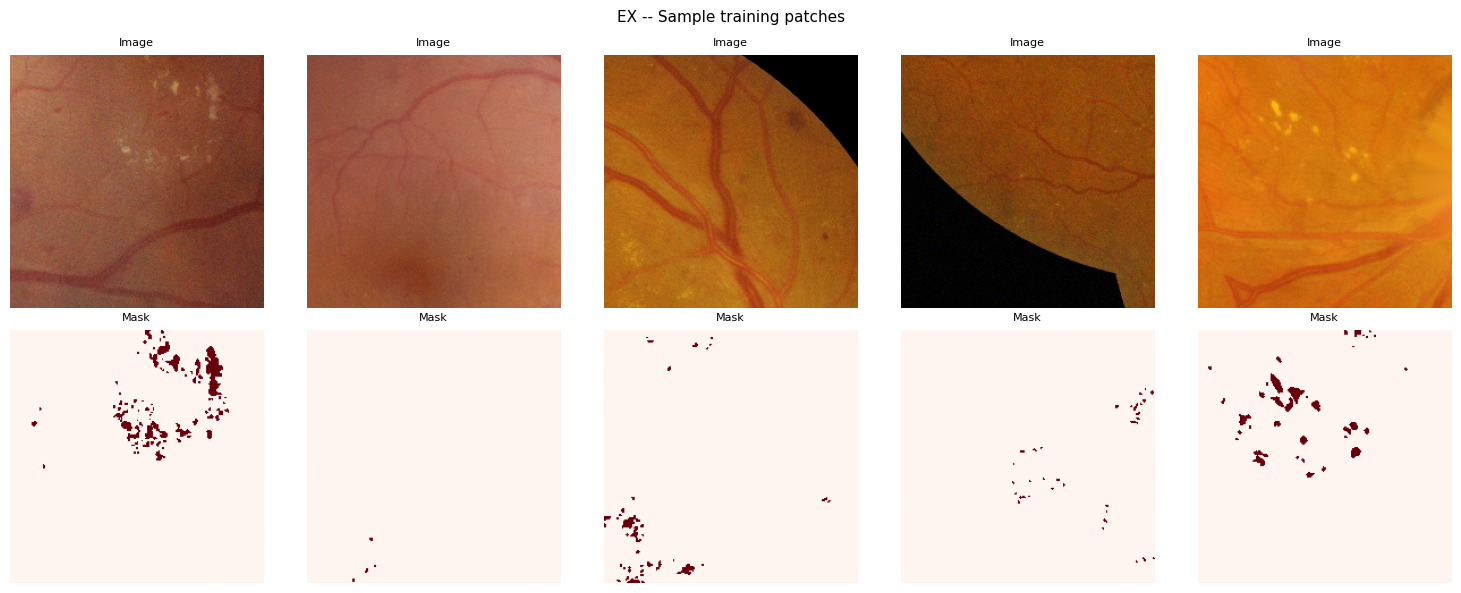

In [3]:
def load_lesion_data(lesion):
    '''Load train/val/test patches from .npz files produced by Notebook 1.
    Images : float32 [0,1]    (N, 224, 224, 3)
    Masks  : float32 {0, 1}   (N, 224, 224, 1)
    '''
    data_dir = os.path.join(DATA_BASE, 'segmentation', lesion)

    def _load(split):
        d    = np.load(os.path.join(data_dir, f'{split}.npz'))
        imgs = d['images'].astype(np.float32) / 255.0        # uint8 [0,255] -> [0,1]
        msks = (d['masks'] > 0).astype(np.float32)           # {0,255} -> {0,1}
        msks = msks[..., np.newaxis]                          # (N,H,W) -> (N,H,W,1)
        return imgs, msks

    X_tr, y_tr = _load('train')
    X_vl, y_vl = _load('val')
    X_te, y_te = _load('test')

    # Shuffle training (patches are ordered by source image in the .npz)
    perm = np.random.permutation(len(X_tr))
    X_tr, y_tr = X_tr[perm], y_tr[perm]

    print(f'[{lesion}] train: {X_tr.shape[0]}  val: {X_vl.shape[0]}  test: {X_te.shape[0]}')
    print(f'         mask positive rate -- train: {y_tr.mean():.4f}  val: {y_vl.mean():.4f}')
    return X_tr, y_tr, X_vl, y_vl, X_te, y_te


X_train, y_train, X_val, y_val, X_test, y_test = load_lesion_data(CURRENT_LESION)

# Preview
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
idx = np.random.choice(len(X_train), 5, replace=False)
for i, j in enumerate(idx):
    axes[0, i].imshow(X_train[j])
    axes[0, i].set_title('Image', fontsize=8)
    axes[0, i].axis('off')
    axes[1, i].imshow(y_train[j, :, :, 0], cmap='Reds', vmin=0, vmax=1)
    axes[1, i].set_title('Mask', fontsize=8)
    axes[1, i].axis('off')
plt.suptitle(f'{CURRENT_LESION} -- Sample training patches', fontsize=11)
plt.tight_layout()
plt.show()

## Cell 4 — Improved U-Net Architecture

Paper Section 3.2 specifies:
- **5-level encoder-decoder** with filter counts [64, 128, 256, 512, 1024]
- **Residual blocks** at each level — two Conv3x3 + BN + ReLU with a skip connection
- **Multi-scale fusion** — predictions at 1x (224px), 1/2x (112px), and 1/4x (56px) are averaged

In [4]:
def residual_block(x, filters, dropout_rate):
    '''Two Conv3x3 + BN + ReLU with a 1x1 residual connection.
    The 1x1 conv on the skip path ensures channel dimensions always match.
    '''
    skip = layers.Conv2D(filters, 1, padding='same', use_bias=False)(x)
    skip = layers.BatchNormalization()(skip)

    x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Add()([x, skip])
    return layers.ReLU()(x)


def build_improved_unet(input_shape=(224, 224, 3), dropout_rate=0.3):
    '''Improved U-Net with residual blocks and multi-scale output fusion.
    Architecture matches paper Section 3.2.
    '''
    inp = layers.Input(shape=input_shape)

    # ---- Encoder ----
    e1 = residual_block(inp, 64,   dropout_rate)   # 224x224x64
    p1 = layers.MaxPooling2D(2)(e1)

    e2 = residual_block(p1,  128,  dropout_rate)   # 112x112x128
    p2 = layers.MaxPooling2D(2)(e2)

    e3 = residual_block(p2,  256,  dropout_rate)   # 56x56x256
    p3 = layers.MaxPooling2D(2)(e3)

    e4 = residual_block(p3,  512,  dropout_rate)   # 28x28x512
    p4 = layers.MaxPooling2D(2)(e4)

    # ---- Bottleneck ----
    b  = residual_block(p4, 1024, dropout_rate)    # 14x14x1024

    # ---- Decoder ----
    d4 = layers.Conv2DTranspose(512, 2, strides=2, padding='same')(b)
    d4 = layers.Concatenate()([d4, e4])
    d4 = residual_block(d4, 512, dropout_rate)     # 28x28

    d3 = layers.Conv2DTranspose(256, 2, strides=2, padding='same')(d4)
    d3 = layers.Concatenate()([d3, e3])
    d3 = residual_block(d3, 256, dropout_rate)     # 56x56

    d2 = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(d3)
    d2 = layers.Concatenate()([d2, e2])
    d2 = residual_block(d2, 128, dropout_rate)     # 112x112

    d1 = layers.Conv2DTranspose(64,  2, strides=2, padding='same')(d2)
    d1 = layers.Concatenate()([d1, e1])
    d1 = residual_block(d1, 64,  dropout_rate)     # 224x224

    # ---- Multi-scale output heads (1x, 1/2x, 1/4x resolutions) ----
    out_1x = layers.Conv2D(1, 1, activation='sigmoid', name='out_1x')(d1)  # 224x224
    out_2x = layers.Conv2D(1, 1, activation='sigmoid', name='out_2x')(d2)  # 112x112
    out_2x = layers.UpSampling2D(size=(2, 2), interpolation='bilinear')(out_2x)
    out_4x = layers.Conv2D(1, 1, activation='sigmoid', name='out_4x')(d3)  # 56x56
    out_4x = layers.UpSampling2D(size=(4, 4), interpolation='bilinear')(out_4x)

    output = layers.Average(name='output')([out_1x, out_2x, out_4x])

    return tf.keras.Model(inputs=inp, outputs=output, name='improved_unet')


# Smoke-test
_m = build_improved_unet()
print(f'Parameters : {_m.count_params():,}')
print(f'Input      : {_m.input.shape}')
print(f'Output     : {_m.output.shape}')
del _m
gc.collect()
tf.keras.backend.clear_session()

I0000 00:00:1782022840.676525      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Parameters : 32,454,403
Input      : (None, 224, 224, 3)
Output     : (None, 224, 224, 1)


## Cell 5 — Loss Functions & Metrics

**Hybrid Loss = Binary Cross-Entropy + Dice Loss** (paper Section 3.2)

BCE penalises individual pixel errors; Dice directly optimises the overlap ratio.
Their combination handles the severe class imbalance in lesion masks (most pixels are background).

In [5]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    '''Dice coefficient (also used as a Keras metric during training).'''
    yt = K.flatten(tf.cast(y_true, tf.float32))
    yp = K.flatten(y_pred)
    inter = K.sum(yt * yp)
    return (2.0 * inter + smooth) / (K.sum(yt) + K.sum(yp) + smooth)


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)


def hybrid_loss(y_true, y_pred):
    '''BCE + Dice (paper Section 3.2).'''
    bce = K.mean(K.binary_crossentropy(tf.cast(y_true, tf.float32), y_pred))
    return bce + dice_loss(y_true, y_pred)


# Sanity check
_yt = tf.constant([[[[1.0]], [[0.0]]], [[[0.0]], [[1.0]]]])
_yp = tf.constant([[[[0.9]], [[0.1]]], [[[0.1]], [[0.9]]]])
print(f'Dice coef   (near-perfect): {dice_coef(_yt, _yp).numpy():.4f}  (expect ~0.95)')
print(f'Hybrid loss (near-perfect): {hybrid_loss(_yt, _yp).numpy():.4f}  (expect ~0.10)')
print('Loss functions ready.')

Dice coef   (near-perfect): 0.9000  (expect ~0.95)
Hybrid loss (near-perfect): 0.2054  (expect ~0.10)
Loss functions ready.


## Cell 6 — Hyperparameter Search (LR Sweep)

The paper uses HSA (40 model builds) to find the optimal LR. On free Colab T4 this
exhausts the 12 GB RAM before completing — confirmed across two crash attempts.

**Replacement: 5-candidate LR sweep, fixed dropout=0.3**
Only 5 model builds. Each runs 15 epochs on 500 patches — enough to clearly separate
good LRs from bad ones. Expected time: ~25 minutes.

In [6]:
def _eval_harmony(lr, dropout_rate, X_sub, y_sub, X_vl, y_vl):
    '''Train fresh model for HSA_WARMUP epochs; return best val Dice.
    GPU memory is cleared before and after each call.
    '''
    tf.keras.backend.clear_session()
    model = build_improved_unet(INPUT_SHAPE, dropout_rate)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=hybrid_loss,
        metrics=[dice_coef]
    )
    history = model.fit(
        X_sub, y_sub,
        validation_data=(X_vl, y_vl),
        epochs=HSA_WARMUP,
        batch_size=BATCH_SIZE,
        verbose=0
    )
    best_vd = max(history.history.get('val_dice_coef', [0.0]))
    del model, history
    gc.collect()
    tf.keras.backend.clear_session()
    return best_vd


def _new_harmony(hm):
    '''Generate a new (lr, dropout) candidate using HMCR and PAR.
    LR is operated in log10 space so bandwidth scales with the search range.
    '''
    log_lrs  = [np.log10(h[0]) for h in hm]
    dropouts = [h[1]            for h in hm]

    if random.random() < HMCR:
        new_log = random.choice(log_lrs)
        if random.random() < PAR:
            new_log += random.uniform(-(LR_LOG_MAX - LR_LOG_MIN) * 0.1,
                                       (LR_LOG_MAX - LR_LOG_MIN) * 0.1)
    else:
        new_log = random.uniform(LR_LOG_MIN, LR_LOG_MAX)
    new_log = float(np.clip(new_log, LR_LOG_MIN, LR_LOG_MAX))

    if random.random() < HMCR:
        new_dr = random.choice(dropouts)
        if random.random() < PAR:
            new_dr += random.uniform(-(DR_MAX - DR_MIN) * 0.1,
                                      (DR_MAX - DR_MIN) * 0.1)
    else:
        new_dr = random.uniform(DR_MIN, DR_MAX)
    new_dr = float(np.clip(new_dr, DR_MIN, DR_MAX))

    return 10 ** new_log, new_dr


def run_hsa(lesion, X_tr, y_tr, X_vl, y_vl):
    '''Full HSA: initialise HMS harmonies + HSA_ITER improvisation steps.
    Returns (best_lr, best_dropout, best_val_dice).
    '''
    print(f'HSA [{lesion}]  HMS={HMS}  iter={HSA_ITER}  HMCR={HMCR}  PAR={PAR}')
    print(f'Warmup: {HSA_WARMUP} epochs on {min(HSA_SUBSET, len(X_tr))} of {len(X_tr)} patches')

    sub_n   = min(HSA_SUBSET, len(X_tr))
    sub_idx = np.random.choice(len(X_tr), sub_n, replace=False)
    X_sub   = X_tr[sub_idx]
    y_sub   = y_tr[sub_idx]

    # Phase 1: Initialise harmony memory
    print('\nPhase 1 -- Initialising harmony memory...')
    hm = []
    for i in range(HMS):
        lr = 10 ** random.uniform(LR_LOG_MIN, LR_LOG_MAX)
        dr = random.uniform(DR_MIN, DR_MAX)
        t0 = time.time()
        vd = _eval_harmony(lr, dr, X_sub, y_sub, X_vl, y_vl)
        hm.append([lr, dr, vd])
        print(f'  [{i+1:02d}/{HMS}] lr={lr:.2e}  dr={dr:.3f}  dice={vd:.4f}  '
              f'({time.time()-t0:.0f}s)')

    hm.sort(key=lambda x: x[2], reverse=True)
    print(f'  Best init: lr={hm[0][0]:.2e}  dr={hm[0][1]:.3f}  dice={hm[0][2]:.4f}')

    # Phase 2: Improvisation
    print(f'\nPhase 2 -- Improvisation ({HSA_ITER} iterations)...')
    for it in range(HSA_ITER):
        new_lr, new_dr = _new_harmony(hm)
        t0 = time.time()
        new_vd = _eval_harmony(new_lr, new_dr, X_sub, y_sub, X_vl, y_vl)
        improved = new_vd > hm[-1][2]
        if improved:
            hm[-1] = [new_lr, new_dr, new_vd]
            hm.sort(key=lambda x: x[2], reverse=True)
        tag = ' <-- IMPROVED' if improved else ''
        print(f'  iter {it+1:02d}/{HSA_ITER}  lr={new_lr:.2e}  dr={new_dr:.3f}  '
              f'dice={new_vd:.4f}  best={hm[0][2]:.4f}  ({time.time()-t0:.0f}s){tag}')

    best_lr, best_dr, best_vd = hm[0]
    print(f'\nHSA complete [{lesion}]:')
    print(f'  Best LR      = {best_lr:.4e}')
    print(f'  Best Dropout = {best_dr:.4f}')
    print(f'  Best ValDice = {best_vd:.4f}')
    return best_lr, best_dr, best_vd


print('HSA functions defined.')

HSA functions defined.


## Cell 7 — Run HSA & Save Best Hyperparameters

**Expected time on T4:**
- EX / HE / MA: ~60–90 min (500 patches x 5 epochs x 40 evaluations)
- SE: ~25 min (fewer training patches)

Results are saved to `hsa_results.json` on Drive. If the session disconnects and you
need to skip straight to full training, re-run Cells 1–3 then this cell — it will
load the saved results automatically.

In [7]:
hsa_json = os.path.join(MODEL_DIR, 'hsa_results.json')

if os.path.exists(hsa_json):
    with open(hsa_json) as f:
        hsa_results = json.load(f)
else:
    hsa_results = {}

if CURRENT_LESION in hsa_results:
    r = hsa_results[CURRENT_LESION]
    best_lr, best_dropout = r['lr'], r['dropout']
    print(f'[{CURRENT_LESION}] Using saved: lr={best_lr:.4e}  dropout={best_dropout:.4f}')
else:
    sub_idx = np.random.choice(len(X_train), min(500, len(X_train)), replace=False)
    X_sub, y_sub = X_train[sub_idx], y_train[sub_idx]

    LR_CANDIDATES = [1e-6, 1e-5, 5e-5, 1e-4, 3e-4]
    results = []
    print(f'LR sweep [{CURRENT_LESION}]: {len(LR_CANDIDATES)} candidates x 15 epochs on {len(X_sub)} patches\n')

    for lr in LR_CANDIDATES:
        tf.keras.backend.clear_session()
        model = build_improved_unet(INPUT_SHAPE, 0.3)
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                      loss=hybrid_loss, metrics=[dice_coef])
        t0 = time.time()
        h = model.fit(X_sub, y_sub, validation_data=(X_val, y_val),
                      epochs=15, batch_size=BATCH_SIZE, verbose=0)
        vd = max(h.history.get('val_dice_coef', [0.0]))
        results.append((lr, vd))
        print(f'  lr={lr:.0e}  val_dice={vd:.4f}  ({time.time()-t0:.0f}s)')
        del model, h
        gc.collect()
        tf.keras.backend.clear_session()

    best_lr, best_vd = max(results, key=lambda x: x[1])
    best_dropout = 0.3
    print(f'\nBest: lr={best_lr:.0e}  val_dice={best_vd:.4f}')

    hsa_results[CURRENT_LESION] = {'lr': best_lr, 'dropout': best_dropout, 'sweep_val_dice': best_vd}
    with open(hsa_json, 'w') as f:
        json.dump(hsa_results, f, indent=2)
    print(f'Saved to {hsa_json}')

print(f'\nFull training: LR={best_lr:.4e}  Dropout={best_dropout:.4f}')


LR sweep [EX]: 5 candidates x 15 epochs on 500 patches



I0000 00:00:1782022859.179196      69 service.cc:152] XLA service 0x7962240019d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782022859.179276      69 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1782022861.633737      69 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782022893.458220      69 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-06-21 06:21:53.300782: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-21 06:21:53.533738: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Syst

  lr=1e-06  val_dice=0.0265  (285s)
  lr=1e-05  val_dice=0.0823  (259s)
  lr=5e-05  val_dice=0.3965  (260s)
  lr=1e-04  val_dice=0.4375  (260s)
  lr=3e-04  val_dice=0.4878  (260s)

Best: lr=3e-04  val_dice=0.4878
Saved to /kaggle/working/models/segmentation/hsa_results.json

Full training: LR=3.0000e-04  Dropout=0.3000


## Cell 8 — Full Training

**Expected time:** 6–12 hours on T4 depending on when early stopping triggers.

The best checkpoint is written to Drive after every validation Dice improvement.
If the session disconnects, re-run Cells 1–3 and 7, then run this cell again —
it loads the existing checkpoint and continues from where it left off.

**OOM errors:** Set `BATCH_SIZE = 8` in Cell 2 and re-run.

In [8]:
model_path = os.path.join(MODEL_DIR, f'unet_{CURRENT_LESION}_best.h5')
hist_path  = os.path.join(MODEL_DIR, f'unet_{CURRENT_LESION}_history.json')

print(f'Training [{CURRENT_LESION}]  LR={best_lr:.4e}  Dropout={best_dropout:.4f}')
print(f'Batch={BATCH_SIZE}  MaxEpochs={MAX_EPOCHS}  ES patience={ES_PATIENCE}')
print(f'Saving to: {model_path}')

tf.keras.backend.clear_session()

if os.path.exists(model_path):
    print('Existing checkpoint found -- resuming...')
    model = tf.keras.models.load_model(
        model_path,
        custom_objects={'hybrid_loss': hybrid_loss, 'dice_coef': dice_coef}
    )
else:
    model = build_improved_unet(INPUT_SHAPE, best_dropout)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=best_lr),
        loss=hybrid_loss,
        metrics=[dice_coef]
    )

model.summary(line_length=80)

cbs = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=model_path,
        monitor='val_dice_coef',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_dice_coef',
        mode='max',
        patience=ES_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_dice_coef',
        mode='max',
        factor=0.5,
        patience=RLROP_WAIT,
        min_lr=1e-7,
        verbose=1
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cbs,
    verbose=1
)

# Save history (merge with prior runs if resuming after disconnect)
new_h = {k: [float(v) for v in vs] for k, vs in history.history.items()}
if os.path.exists(hist_path):
    with open(hist_path) as f:
        old_h = json.load(f)
    for k in new_h:
        old_h.setdefault(k, []).extend(new_h[k])
    new_h = old_h
with open(hist_path, 'w') as f:
    json.dump(new_h, f)

best_val = max(new_h['val_dice_coef'])
print(f'\nTraining complete [{CURRENT_LESION}]')
print(f'Best val Dice : {best_val:.4f}')
print(f'Epochs run    : {len(new_h["loss"])}')
print(f'Model saved   : {model_path}')

Training [EX]  LR=3.0000e-04  Dropout=0.3000
Batch=8  MaxEpochs=500  ES patience=50
Saving to: /kaggle/working/models/segmentation/unet_EX_best.h5


Model: "improved_unet"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer           │ (None, 224, 224,  │           0 │ -                  │
│ (InputLayer)          │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_1 (Conv2D)     │ (None, 224, 224,  │       1,728 │ input_layer[0][0]  │
│                       │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_1 │ (None, 224, 224,  │         256 │ conv2d_1[0][0]     │
│ (BatchNormalization)  │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu (ReLU)          │ (None, 224, 224,  │           0 │ batch_normalizati… │
│                       │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dropout (Dropout)     │ (None, 224, 224,  │           0 │ re_lu[0][0]        │
│                       │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_2 (Conv2D)     │ (None, 224, 224,  │      36,864 │ dropout[0][0]      │
│                       │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d (Conv2D)       │ (None, 224, 224,  │         192 │ input_layer[0][0]  │
│                       │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_2 │ (None, 224, 224,  │         256 │ conv2d_2[0][0]     │
│ (BatchNormalization)  │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization   │ (None, 224, 224,  │         256 │ conv2d[0][0]       │
│ (BatchNormalization)  │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ add (Add)             │ (None, 224, 224,  │           0 │ batch_normalizati… │
│                       │ 64)               │             │ batch_normalizati… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_1 (ReLU)        │ (None, 224, 224,  │           0 │ add[0][0]          │
│                       │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ max_pooling2d         │ (None, 112, 112,  │           0 │ re_lu_1[0][0]      │
│ (MaxPooling2D)        │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_4 (Conv2D)     │ (None, 112, 112,  │      73,728 │ max_pooling2d[0][… │
│                       │ 128)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_4 │ (None, 112, 112,  │         512 │ conv2d_4[0][0]     │
│ (BatchNormalization)  │ 128)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_2 (ReLU)        │ (None, 112, 112,  │           0 │ batch_normalizati… │
│                       │ 128)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dropout_1 (Dropout)   │ (None, 112, 112,  │           0 │ re_lu_2[0][0]      │
│                       │ 128) 

 Total params: 32,454,403 (123.80 MB)

 Trainable params: 32,436,739 (123.74 MB)

...


Epoch 43: finished saving model to /kaggle/working/models/segmentation/unet_EX_best.h5
660/660 ━━━━━━━━━━━━━━━━━━━━ 137s 208ms/step - dice_coef: 0.7351 - loss: 0.2833 - val_dice_coef: 0.5714 - val_loss: 0.4470 - learning_rate: 3.0000e-04
Epoch 44/500
660/660 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - dice_coef: 0.7391 - loss: 0.2793
Epoch 44: val_dice_coef did not improve from 0.57144
660/660 ━━━━━━━━━━━━━━━━━━━━ 136s 206ms/step - dice_coef: 0.7363 - loss: 0.2820 - val_dice_coef: 0.5534 - val_loss: 0.4658 - learning_rate: 3.0000e-04
Epoch 45/500
660/660 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - dice_coef: 0.7406 - loss: 0.2775
Epoch 45: val_dice_coef did not improve from 0.57144
660/660 ━━━━━━━━━━━━━━━━━━━━ 136s 206ms/step - dice_coef: 0.7377 - loss: 0.2804 - val_dice_coef: 0.5524 - val_loss: 0.4671 - learning_rate: 3.0000e-04
Epoch 46/500
660/660 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - dice_coef: 0.7420 - loss: 0.2760
Epoch 46: val_dice_coef did not improve from 0.57144
660/660 ━━━━━━━━━━━━━━━━━━━


Epoch 56: finished saving model to /kaggle/working/models/segmentation/unet_EX_best.h5
660/660 ━━━━━━━━━━━━━━━━━━━━ 138s 208ms/step - dice_coef: 0.7484 - loss: 0.2684 - val_dice_coef: 0.5773 - val_loss: 0.4414 - learning_rate: 3.0000e-04
Epoch 57/500
660/660 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - dice_coef: 0.7533 - loss: 0.2633
Epoch 57: val_dice_coef did not improve from 0.57735
660/660 ━━━━━━━━━━━━━━━━━━━━ 136s 206ms/step - dice_coef: 0.7506 - loss: 0.2659 - val_dice_coef: 0.5629 - val_loss: 0.4557 - learning_rate: 3.0000e-04
Epoch 58/500
660/660 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - dice_coef: 0.7542 - loss: 0.2622
Epoch 58: val_dice_coef did not improve from 0.57735
660/660 ━━━━━━━━━━━━━━━━━━━━ 136s 206ms/step - dice_coef: 0.7513 - loss: 0.2651 - val_dice_coef: 0.5599 - val_loss: 0.4600 - learning_rate: 3.0000e-04
Epoch 59/500
660/660 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - dice_coef: 0.7550 - loss: 0.2614
Epoch 59: val_dice_coef did not improve from 0.57735
660/660 ━━━━━━━━━━━━━━━━━━━


Epoch 77: finished saving model to /kaggle/working/models/segmentation/unet_EX_best.h5
660/660 ━━━━━━━━━━━━━━━━━━━━ 137s 208ms/step - dice_coef: 0.7658 - loss: 0.2486 - val_dice_coef: 0.5774 - val_loss: 0.4419 - learning_rate: 1.5000e-04
Epoch 78/500
660/660 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - dice_coef: 0.7698 - loss: 0.2446
Epoch 78: val_dice_coef did not improve from 0.57736
660/660 ━━━━━━━━━━━━━━━━━━━━ 136s 206ms/step - dice_coef: 0.7673 - loss: 0.2470 - val_dice_coef: 0.5736 - val_loss: 0.4461 - learning_rate: 1.5000e-04
Epoch 79/500
660/660 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - dice_coef: 0.7707 - loss: 0.2435
Epoch 79: val_dice_coef did not improve from 0.57736
660/660 ━━━━━━━━━━━━━━━━━━━━ 136s 206ms/step - dice_coef: 0.7683 - loss: 0.2459 - val_dice_coef: 0.5700 - val_loss: 0.4498 - learning_rate: 1.5000e-04
Epoch 80/500
660/660 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - dice_coef: 0.7717 - loss: 0.2424
Epoch 80: val_dice_coef did not improve from 0.57736
660/660 ━━━━━━━━━━━━━━━━━━━


Epoch 89: finished saving model to /kaggle/working/models/segmentation/unet_EX_best.h5
660/660 ━━━━━━━━━━━━━━━━━━━━ 137s 208ms/step - dice_coef: 0.7738 - loss: 0.2397 - val_dice_coef: 0.5775 - val_loss: 0.4429 - learning_rate: 1.5000e-04
Epoch 90/500
660/660 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - dice_coef: 0.7766 - loss: 0.2369
Epoch 90: val_dice_coef did not improve from 0.57747
660/660 ━━━━━━━━━━━━━━━━━━━━ 136s 206ms/step - dice_coef: 0.7740 - loss: 0.2394 - val_dice_coef: 0.5736 - val_loss: 0.4466 - learning_rate: 1.5000e-04
Epoch 91/500
660/660 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - dice_coef: 0.7769 - loss: 0.2365
Epoch 91: val_dice_coef did not improve from 0.57747
660/660 ━━━━━━━━━━━━━━━━━━━━ 136s 206ms/step - dice_coef: 0.7744 - loss: 0.2389 - val_dice_coef: 0.5736 - val_loss: 0.4471 - learning_rate: 1.5000e-04
Epoch 92/500
660/660 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - dice_coef: 0.7773 - loss: 0.2360
Epoch 92: val_dice_coef did not improve from 0.57747
660/660 ━━━━━━━━━━━━━━━━━━━


Epoch 96: finished saving model to /kaggle/working/models/segmentation/unet_EX_best.h5
660/660 ━━━━━━━━━━━━━━━━━━━━ 137s 208ms/step - dice_coef: 0.7763 - loss: 0.2368 - val_dice_coef: 0.5781 - val_loss: 0.4424 - learning_rate: 1.5000e-04
Epoch 97/500
660/660 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - dice_coef: 0.7791 - loss: 0.2340
Epoch 97: val_dice_coef did not improve from 0.57812
660/660 ━━━━━━━━━━━━━━━━━━━━ 136s 206ms/step - dice_coef: 0.7766 - loss: 0.2364 - val_dice_coef: 0.5709 - val_loss: 0.4497 - learning_rate: 1.5000e-04
Epoch 98/500
660/660 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - dice_coef: 0.7795 - loss: 0.2336
Epoch 98: val_dice_coef did not improve from 0.57812
660/660 ━━━━━━━━━━━━━━━━━━━━ 136s 206ms/step - dice_coef: 0.7769 - loss: 0.2361 - val_dice_coef: 0.5695 - val_loss: 0.4510 - learning_rate: 1.5000e-04
Epoch 99/500
660/660 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - dice_coef: 0.7798 - loss: 0.2332
Epoch 99: val_dice_coef did not improve from 0.57812
660/660 ━━━━━━━━━━━━━━━━━━━

## Cell 9 — Evaluate on Test Set & Plot Curves

2026-06-21 12:15:19.032218: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-21 12:15:19.261483: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


[EX] Test Dice: 0.5138  Test Loss: 0.4943
Paper target Dice: 0.88


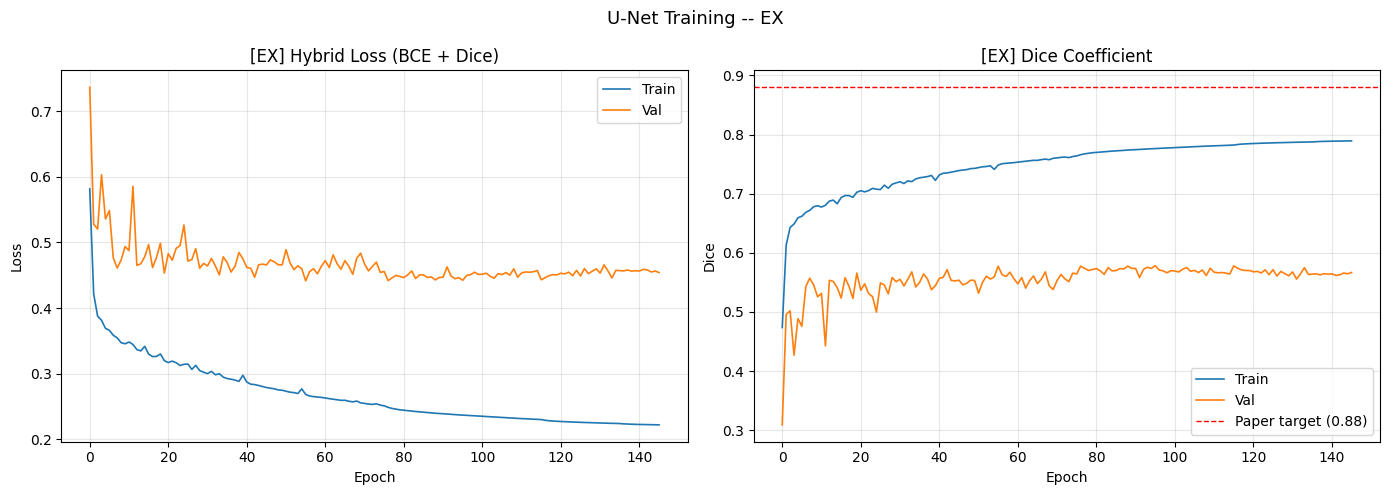

2026-06-21 12:15:26.712512: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-21 12:15:26.945099: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


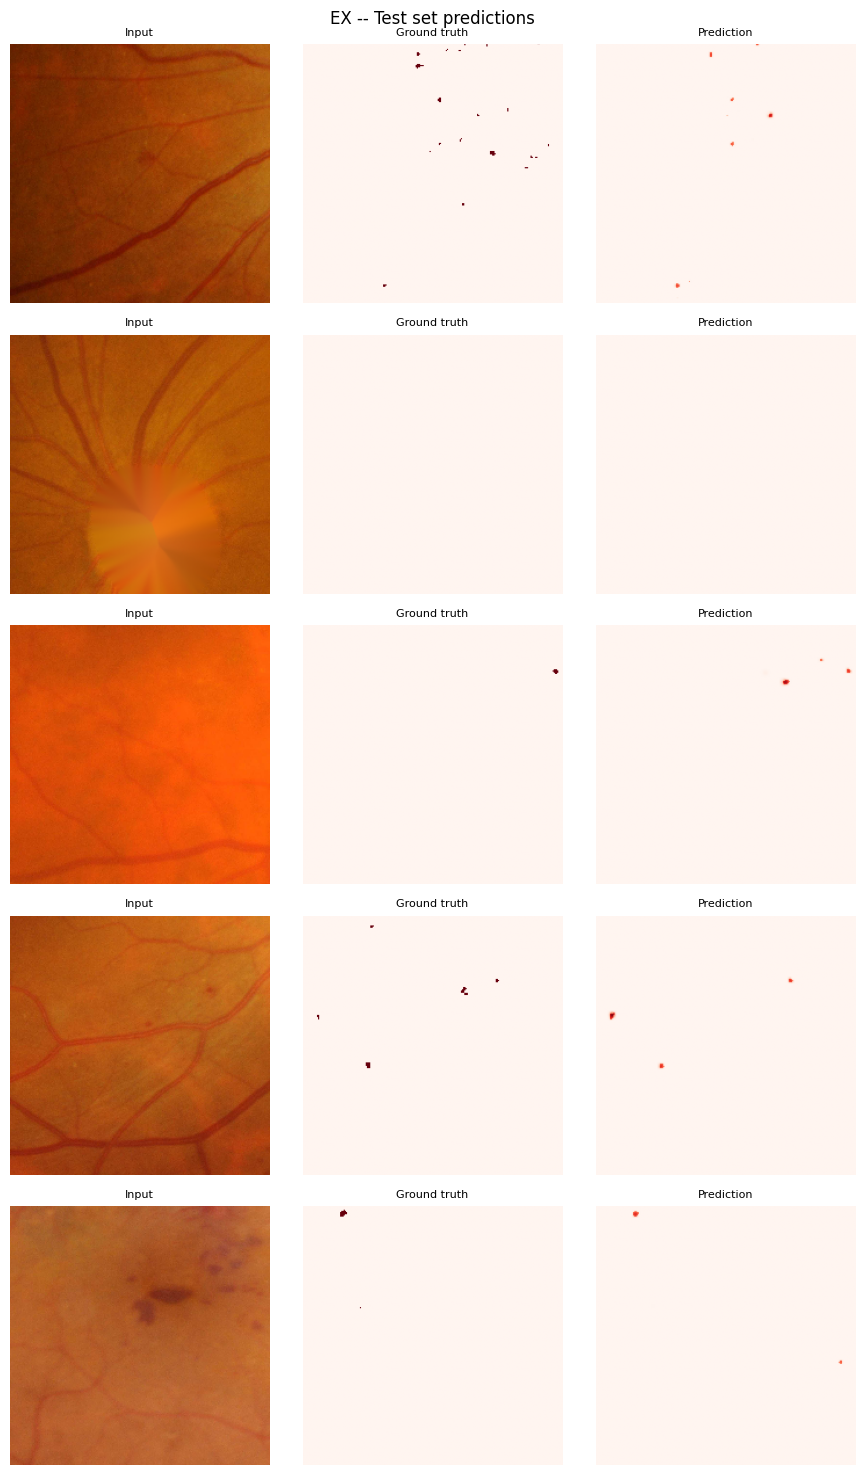

Plots saved to /kaggle/working/models/segmentation
Change CURRENT_LESION in Cell 2 and re-run for the next lesion.


In [9]:
# Load best saved model
best_model = tf.keras.models.load_model(
    model_path,
    custom_objects={'hybrid_loss': hybrid_loss, 'dice_coef': dice_coef}
)
test_loss, test_dice = best_model.evaluate(X_test, y_test, batch_size=BATCH_SIZE, verbose=0)
print(f'[{CURRENT_LESION}] Test Dice: {test_dice:.4f}  Test Loss: {test_loss:.4f}')

targets = {'EX': 0.8800, 'HE': 0.8686, 'MA': 0.7349, 'SE': 0.8927}
print(f'Paper target Dice: {targets.get(CURRENT_LESION, "N/A")}')

# Training curves
with open(hist_path) as f:
    hist = json.load(f)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(hist['loss'],     label='Train', linewidth=1.2)
ax1.plot(hist['val_loss'], label='Val',   linewidth=1.2)
ax1.set_title(f'[{CURRENT_LESION}] Hybrid Loss (BCE + Dice)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(hist['dice_coef'],     label='Train', linewidth=1.2)
ax2.plot(hist['val_dice_coef'], label='Val',   linewidth=1.2)
t = targets.get(CURRENT_LESION, 0)
if t:
    ax2.axhline(t, color='red', linestyle='--', linewidth=1, label=f'Paper target ({t:.2f})')
ax2.set_title(f'[{CURRENT_LESION}] Dice Coefficient')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Dice')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle(f'U-Net Training -- {CURRENT_LESION}', fontsize=13)
plt.tight_layout()
fig.savefig(os.path.join(MODEL_DIR, f'unet_{CURRENT_LESION}_curves.png'), dpi=120)
plt.show()

# Sample predictions on test set
n_show = min(5, len(X_test))
s_idx  = np.random.choice(len(X_test), n_show, replace=False)
preds  = best_model.predict(X_test[s_idx], verbose=0)

fig2, axes = plt.subplots(n_show, 3, figsize=(9, 3 * n_show))
for i, idx in enumerate(s_idx):
    axes[i, 0].imshow(X_test[idx])
    axes[i, 0].set_title('Input', fontsize=8)
    axes[i, 0].axis('off')
    axes[i, 1].imshow(y_test[idx, :, :, 0], cmap='Reds', vmin=0, vmax=1)
    axes[i, 1].set_title('Ground truth', fontsize=8)
    axes[i, 1].axis('off')
    axes[i, 2].imshow(preds[i, :, :, 0], cmap='Reds', vmin=0, vmax=1)
    axes[i, 2].set_title('Prediction', fontsize=8)
    axes[i, 2].axis('off')

plt.suptitle(f'{CURRENT_LESION} -- Test set predictions', fontsize=12)
plt.tight_layout()
fig2.savefig(os.path.join(MODEL_DIR, f'unet_{CURRENT_LESION}_predictions.png'), dpi=120)
plt.show()

print(f'Plots saved to {MODEL_DIR}')
print('Change CURRENT_LESION in Cell 2 and re-run for the next lesion.')